In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import imdb

In [2]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)


In [3]:
# num words oznacza ze w treningowym zbiorze danych zostanie zachowanych tylko 10 k slow wystepujacych najczesciej w tym zbiorze danych, slowa 
#wystepujace rzadziej beda pominiete. rozwiazanie te umozliwia prace z wektorem danych o rozmiarze umozliwiajacynm jego przetwarzanie

In [4]:
train_data

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [5]:
train_labels

array([1, 0, 0, ..., 0, 1, 0], shape=(25000,))

In [6]:
max([max(sequence) for sequence in train_data])

9999

In [7]:
word_index = imdb.get_word_index()
reverse_word_index = dict(
    [(value,key) for (key, value) in word_index.items()])
decoded_review = ' '.join(
    [reverse_word_index.get(i - 3, '?') for i in train_data[0]])

In [8]:
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [9]:
# przetlumaczona caly kod z numerycznych na tekst - train data [0]

In [10]:
# zamiana na wektory liczb 0 i 1

In [11]:
import numpy as np

In [12]:
def vectorize_sequences(sequences, dimension = 10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results
x_train = vectorize_sequences(train_data)
x_train

array([[0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]], shape=(25000, 10000))

In [13]:
x_test = vectorize_sequences(test_data)
x_test

array([[0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]], shape=(25000, 10000))

In [14]:
train_labels

array([1, 0, 0, ..., 0, 1, 0], shape=(25000,))

In [15]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

In [16]:
y_train

array([1., 0., 0., ..., 0., 1., 0.], shape=(25000,), dtype=float32)

In [17]:
from keras import models
from keras import layers

In [18]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

C:\Users\litwi\Desktop\python-learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# kompilacja modelu

In [20]:
model.compile(optimizer = 'rmsprop',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

In [21]:
# konfiguracja optymalizatora

In [22]:
from keras import optimizers

In [23]:
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [24]:
# korzystanie z wlasnych funkcji straty i metryki

In [25]:
from keras import losses
from keras import metrics

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

In [26]:
# tworzenie zbioru walidacyjnego

In [27]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

In [28]:
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [29]:
# trenowanie modelu

In [30]:
model.compile(optimizer = 'rmsprop',
              loss = 'binary_crossentropy',
              metrics = ['acc'])

In [31]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.7593 - loss: 0.5492 - val_acc: 0.8549 - val_loss: 0.4273
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.8930 - loss: 0.3371 - val_acc: 0.8774 - val_loss: 0.3286
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9183 - loss: 0.2507 - val_acc: 0.8813 - val_loss: 0.3027
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9348 - loss: 0.2034 - val_acc: 0.8876 - val_loss: 0.2773
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9453 - loss: 0.1684 - val_acc: 0.8877 - val_loss: 0.2765
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9553 - loss: 0.1421 - val_acc: 0.8860 - val_loss: 0.2836
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9604 - loss: 0.1239 - val_acc: 0.8840 - val_loss: 0.2921
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9693 - loss: 0.1054 - val_acc: 0.8659 - val_loss: 0.3663
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.9733 - loss:

In [32]:
history_dict = history.history
history_dict.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

In [33]:
import matplotlib.pyplot as plt

In [34]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [35]:
epochs = range(1, len(acc) + 1)

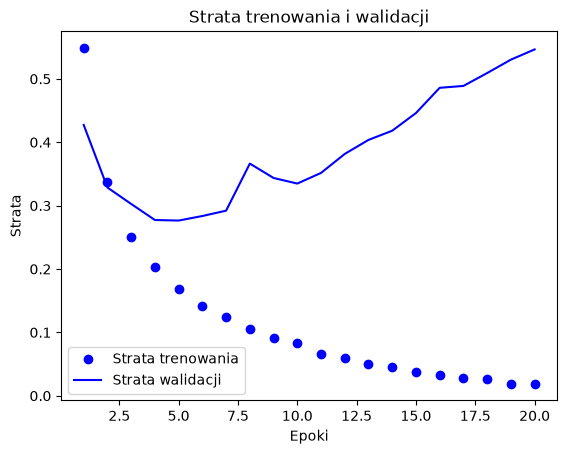

In [36]:
plt.plot(epochs, loss, 'bo', label='Strata trenowania')
plt.plot(epochs, val_loss, 'b', label='Strata walidacji')
plt.title('Strata trenowania i walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()

plt.show()

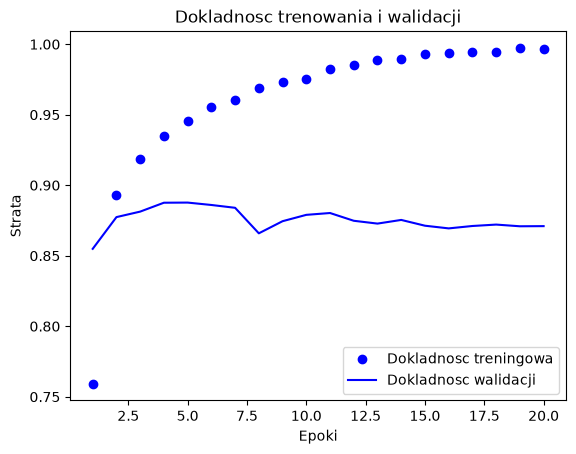

In [37]:
plt.clf()
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']

plt.plot(epochs, acc, 'bo', label='Dokladnosc treningowa')
plt.plot(epochs, val_acc, 'b', label='Dokladnosc walidacji')
plt.title('Dokladnosc trenowania i walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()

plt.show()

In [38]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer = 'rmsprop',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7999 - loss: 0.4905
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9007 - loss: 0.2867
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9215 - loss: 0.2207
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9335 - loss: 0.1881
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - accuracy: 0.8837 - loss: 0.2917


In [39]:
results

[0.2916746437549591, 0.883679986000061]

In [40]:
model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 553us/step


array([[0.21206778],
       [0.9999021 ],
       [0.6584912 ],
       ...,
       [0.0888355 ],
       [0.07340107],
       [0.53982496]], shape=(25000, 1), dtype=float32)

# zadanie 2

In [41]:
from keras.datasets import reuters

In [42]:
(train_data_2, train_labels_2), (test_data_2, test_labels_2) = reuters.load_data(num_words=10000)

In [43]:
len(train_data_2)

8982

In [44]:
len(test_data_2)

2246

In [45]:
train_data_2

array([list([1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]),
       list([1, 3267, 699, 3434, 2295, 56, 2, 7511, 9, 56, 3906, 1073, 81, 5, 1198, 57, 366, 737, 132, 20, 4093, 7, 2, 49, 2295, 2, 1037, 3267, 699, 3434, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2295, 2, 2, 775, 7, 48, 34, 191, 44, 35, 1795, 505, 17, 12]),
       list([1, 53, 12, 284, 15, 14, 272, 26, 53, 959, 32, 818, 15, 14, 272, 26, 39, 684, 70, 11, 14, 12, 3886, 18, 180, 183, 187, 70, 11, 14, 102, 32, 11, 29, 53, 44, 704, 15, 14, 19, 758, 15, 53, 959, 47, 1013, 15, 14, 19, 132, 15, 39, 965, 32, 11, 14, 147, 72, 11, 180, 183, 187, 44, 11, 14, 102, 19, 11, 123, 186, 90, 67, 960, 4, 78, 13, 68, 467, 511, 110,

In [46]:
# dekodowanie indeksow

In [47]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data_2[0]])

In [48]:
decoded_newswire

'? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3'

In [49]:
train_labels_2

array([ 3,  4,  3, ..., 25,  3, 25], shape=(8982,))

In [50]:
train_data_2.shape

(8982,)

In [51]:
def vectorize_sequences(sequences, dimension = 10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results
x_train_2 = vectorize_sequences(train_data_2)
x_test_2 = vectorize_sequences(test_data_2)

In [52]:
train_labels_2

array([ 3,  4,  3, ..., 25,  3, 25], shape=(8982,))

In [53]:
test_labels_2

array([ 3, 10,  1, ...,  3,  3, 24], shape=(2246,))

In [54]:
from keras.utils import to_categorical

In [55]:
one_hot_train_labels = to_categorical(train_labels_2)
one_hot_test_labels = to_categorical(test_labels_2)

In [56]:
# definicja modelu

In [57]:
model_2 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

In [58]:
# kompilacja modelu

In [59]:
model_2.compile(optimizer='rmsprop',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])

In [60]:
# zbior kontrolny 

In [61]:
x_val_2 = x_train_2[:1000]
partial_x_train_2 = x_train_2[1000:]

In [62]:
partial_x_train_2

array([[0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]], shape=(7982, 10000))

In [63]:
y_val_2 = one_hot_train_labels[:1000]
partial_y_train_2 = one_hot_train_labels[1000:]

In [64]:
history_2 = model_2.fit(partial_x_train_2,
                        partial_y_train_2,
                        epochs=20,
                        batch_size=512,
                        validation_data=(x_val_2, y_val_2))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4807 - loss: 2.7138 - val_accuracy: 0.5820 - val_loss: 1.8463
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6632 - loss: 1.5679 - val_accuracy: 0.6820 - val_loss: 1.3973
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7309 - loss: 1.2135 - val_accuracy: 0.7230 - val_loss: 1.2181
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7825 - loss: 0.9976 - val_accuracy: 0.7480 - val_loss: 1.0962
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8202 - loss: 0.8295 - val_accuracy: 0.7710 - val_loss: 1.0296
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8504 - loss: 0.6918 - val_accuracy: 0.8000 - val_loss: 0.9499
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8765 - loss: 0.5786 - val_accuracy: 0.7990 - val_loss: 0.9191
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8999 - loss: 0.4876 - val_accuracy: 0.8010 - val_loss

In [65]:
loss_2 = history_2.history['loss']
val_loss_2 = history_2.history['val_loss']
epochs = range(1, len(loss) + 1)

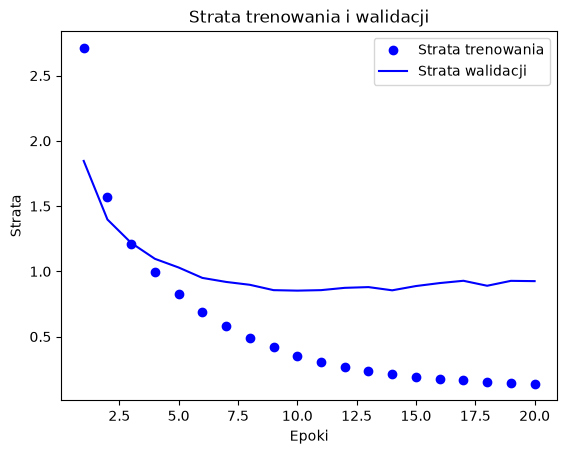

In [66]:
plt.plot(epochs, loss_2, 'bo', label='Strata trenowania')
plt.plot(epochs, val_loss_2, 'b', label='Strata walidacji')
plt.title('Strata trenowania i walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()

plt.show()

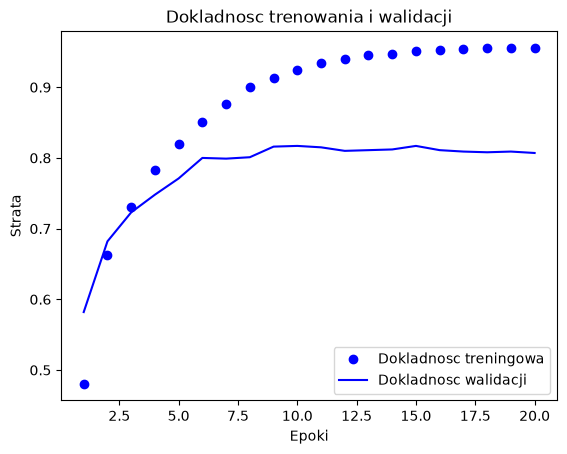

In [67]:
plt.clf()
acc_2 = history_2.history['accuracy']
val_acc_2 = history_2.history['val_accuracy']

plt.plot(epochs, acc_2, 'bo', label='Dokladnosc treningowa')
plt.plot(epochs, val_acc_2, 'b', label='Dokladnosc walidacji')
plt.title('Dokladnosc trenowania i walidacji')
plt.xlabel('Epoki')
plt.ylabel('Strata')
plt.legend()

plt.show()

In [68]:
# tam gdzie val loss jest najmniejszy i val acc najwieksze wybieramy to 

In [69]:
# trenujemy znowu od nowa na 9 epokach

In [70]:
model_2 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

model_2.compile(optimizer='rmsprop',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])

model_2.fit(partial_x_train_2,
            partial_y_train_2,
            epochs=8,
            batch_size=512,
            validation_data=(x_val_2, y_val_2))
results = model_2.evaluate(x_test_2, one_hot_test_labels)

Epoch 1/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5286 - loss: 2.5652 - val_accuracy: 0.6310 - val_loss: 1.7246
Epoch 2/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6901 - loss: 1.4680 - val_accuracy: 0.6840 - val_loss: 1.3430
Epoch 3/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7516 - loss: 1.1419 - val_accuracy: 0.7360 - val_loss: 1.1870
Epoch 4/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8001 - loss: 0.9296 - val_accuracy: 0.7580 - val_loss: 1.0768
Epoch 5/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8287 - loss: 0.7705 - val_accuracy: 0.7810 - val_loss: 0.9946
Epoch 6/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8622 - loss: 0.6361 - val_accuracy: 0.7950 - val_loss: 0.9457
Epoch 7/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8872 - loss: 0.5292 - val_accuracy: 0.7870 - val_loss: 0.9391
Epoch 8/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9035 - loss: 0.4444 - val_accuracy: 0.8030 - val_loss: 0.8994

In [71]:
results

[0.9780414700508118, 0.7751558423042297]

In [72]:
# generowanie przewidywan

In [73]:
predictions_2 = model_2.predict(x_test_2)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step


In [74]:
len(predictions_2)

2246

In [75]:
predictions_2.shape

(2246, 46)

In [76]:
np.argmax(predictions_2[0])

np.int64(3)

In [77]:
# 3 oznacza ze ten artykul nalezy do kategorii 3

In [78]:
# teraz pokazemy dlaczego warto tworzyc odpowiednio duze warstwy 

In [79]:
model_2 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(4, activation='relu'),
    layers.Dense(46, activation='softmax')
])

model_2.compile(optimizer='rmsprop',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])

model_2.fit(partial_x_train_2,
            partial_y_train_2,
            epochs=20,
            batch_size=128,
            validation_data=(x_val_2, y_val_2))
results_3 = model_2.evaluate(x_test_2, one_hot_test_labels)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3400 - loss: 3.0302 - val_accuracy: 0.3770 - val_loss: 2.3958
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4717 - loss: 2.0287 - val_accuracy: 0.5730 - val_loss: 1.7707
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5781 - loss: 1.5850 - val_accuracy: 0.5920 - val_loss: 1.5780
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6145 - loss: 1.4129 - val_accuracy: 0.6090 - val_loss: 1.5117
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6374 - loss: 1.2772 - val_accuracy: 0.6330 - val_loss: 1.4047
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6804 - loss: 1.1494 - val_accuracy: 0.6490 - val_loss: 1.3617
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7141 - loss: 1.0434 - val_accuracy: 0.6730 - val_loss: 1.3216
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7382 - loss: 0.9523 - val_accuracy: 0.6810 - val_loss:

In [80]:
results_3

[1.7054567337036133, 0.7105966210365295]

In [81]:
# dokladnosc spadla o okolo 8

In [82]:
# teraz sprobujemy dac warsty po 128 

In [83]:
# siec ktora ma jedna warstwe

In [88]:
model_4 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

model_4.compile(optimizer='rmsprop',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])

model_4.fit(partial_x_train_2,
            partial_y_train_2,
            epochs=20,
            batch_size=128,
            validation_data=(x_val_2, y_val_2))
results_4 = model_4.evaluate(x_test_2, one_hot_test_labels)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6371 - loss: 1.9265 - val_accuracy: 0.7320 - val_loss: 1.2583
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7868 - loss: 0.9958 - val_accuracy: 0.7970 - val_loss: 0.9894
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8579 - loss: 0.6946 - val_accuracy: 0.8170 - val_loss: 0.8828
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8995 - loss: 0.5092 - val_accuracy: 0.8300 - val_loss: 0.8308
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9207 - loss: 0.3864 - val_accuracy: 0.8390 - val_loss: 0.7923
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9356 - loss: 0.3028 - val_accuracy: 0.8230 - val_loss: 0.8036
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9409 - loss: 0.2477 - val_accuracy: 0.8350 - val_loss: 0.7944
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9463 - loss: 0.2100 - val_accuracy: 0.8300 - val_loss:

In [89]:
results_4

[1.0535858869552612, 0.796972393989563]

In [90]:
model_5 = models.Sequential([
    layers.Input(shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

model_5.compile(optimizer='rmsprop',
              loss= 'categorical_crossentropy',
              metrics=['accuracy'])

model_5.fit(partial_x_train_2,
            partial_y_train_2,
            epochs=20,
            batch_size=128,
            validation_data=(x_val_2, y_val_2))
results_5 = model_5.evaluate(x_test_2, one_hot_test_labels)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5879 - loss: 1.9443 - val_accuracy: 0.7110 - val_loss: 1.3286
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7652 - loss: 1.0758 - val_accuracy: 0.7550 - val_loss: 1.1002
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8350 - loss: 0.7456 - val_accuracy: 0.7790 - val_loss: 1.0094
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8845 - loss: 0.5208 - val_accuracy: 0.8030 - val_loss: 0.9495
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9206 - loss: 0.3666 - val_accuracy: 0.8080 - val_loss: 0.9451
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9370 - loss: 0.2781 - val_accuracy: 0.7610 - val_loss: 1.2477
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9479 - loss: 0.2268 - val_accuracy: 0.8110 - val_loss: 1.0538
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9509 - loss: 0.1965 - val_accuracy: 0.7770 - val_loss:

In [91]:
results_5

[1.2944117784500122, 0.7791629433631897]

# zadanie 3 

In [92]:
from keras.datasets import boston_housing

In [97]:
(train_data_3, train_targets_3), (test_data_3, test_targets_3) = boston_housing.load_data()

In [98]:
train_data_3.shape

(404, 13)

In [99]:
test_data_3.shape

(102, 13)

In [100]:
train_targets_3

array([15.2, 42.3, 50. , 21.1, 17.7, 18.5, 11.3, 15.6, 15.6, 14.4, 12.1,
       17.9, 23.1, 19.9, 15.7,  8.8, 50. , 22.5, 24.1, 27.5, 10.9, 30.8,
       32.9, 24. , 18.5, 13.3, 22.9, 34.7, 16.6, 17.5, 22.3, 16.1, 14.9,
       23.1, 34.9, 25. , 13.9, 13.1, 20.4, 20. , 15.2, 24.7, 22.2, 16.7,
       12.7, 15.6, 18.4, 21. , 30.1, 15.1, 18.7,  9.6, 31.5, 24.8, 19.1,
       22. , 14.5, 11. , 32. , 29.4, 20.3, 24.4, 14.6, 19.5, 14.1, 14.3,
       15.6, 10.5,  6.3, 19.3, 19.3, 13.4, 36.4, 17.8, 13.5, 16.5,  8.3,
       14.3, 16. , 13.4, 28.6, 43.5, 20.2, 22. , 23. , 20.7, 12.5, 48.5,
       14.6, 13.4, 23.7, 50. , 21.7, 39.8, 38.7, 22.2, 34.9, 22.5, 31.1,
       28.7, 46. , 41.7, 21. , 26.6, 15. , 24.4, 13.3, 21.2, 11.7, 21.7,
       19.4, 50. , 22.8, 19.7, 24.7, 36.2, 14.2, 18.9, 18.3, 20.6, 24.6,
       18.2,  8.7, 44. , 10.4, 13.2, 21.2, 37. , 30.7, 22.9, 20. , 19.3,
       31.7, 32. , 23.1, 18.8, 10.9, 50. , 19.6,  5. , 14.4, 19.8, 13.8,
       19.6, 23.9, 24.5, 25. , 19.9, 17.2, 24.6, 13

In [119]:
import sklearn 
from sklearn.preprocessing import StandardScaler

In [120]:
scaler = StandardScaler()
scaled_train_data = scaler.fit_transform(train_data_3)
scaled_test_data = scaler.transform(test_data_3)

In [123]:
def build_model():
    model =models.Sequential([
        layers.Input(shape=(train_data_3.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)])

    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

In [124]:
# robimy teraz k skladowa walidacje krzyzowa 
# dzielimy zbior treningowy na 4 foldy i wyciagamy mae z kazdego i dzielimy przez ilosc foldow i to bedzie nasz sredni blad

In [140]:
k = 4
num_val_samples = len(train_data_3) // k 
num_epochs = 100
all_scores = []
for i in range(k):
    print('processing fold #', i)
    val_data = scaled_train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets_3[i * num_val_samples: (i + 1) * num_val_samples]

    partial_train_data = np.concatenate(
    [scaled_train_data[:i * num_val_samples],
    scaled_train_data[(i + 1) * num_val_samples:]], axis=0)

    partial_train_targets = np.concatenate(
    [train_targets_3[:i * num_val_samples],
    train_targets_3[(i + 1) * num_val_samples:]], axis=0)

    model_6 = build_model()
    model_6.fit(partial_train_data, partial_train_targets, epochs = num_epochs, batch_size = 1, verbose = 0)
    val_mse, val_mae = model_6.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)
    
all_scores

processing fold # 0
processing fold # 1
processing fold # 2
processing fold # 3


[2.2442307472229004,
 2.5469982624053955,
 2.9239308834075928,
 2.7070462703704834]

In [141]:
all_mae_histories = [] 
num_epochs = 500
for i in range(k):
    print('processing fold #', i)
    val_data = scaled_train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets_3[i * num_val_samples: (i + 1) * num_val_samples]

    partial_train_data = np.concatenate(
    [scaled_train_data[:i * num_val_samples],
    scaled_train_data[(i + 1) * num_val_samples:]], axis=0)

    partial_train_targets = np.concatenate(
    [train_targets_3[:i * num_val_samples],
    train_targets_3[(i + 1) * num_val_samples:]], axis=0)

    model_6 = build_model()
    
    history = model_6.fit(
        partial_train_data, 
        partial_train_targets,
        validation_data=(val_data, val_targets),
        epochs=num_epochs, 
        batch_size=16, 
        verbose=0
    )
    
    mae_history = history.history['val_mae']
    all_mae_histories.append(mae_history)

    
avg_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]
avg_mae_history

processing fold # 0
processing fold # 1
processing fold # 2
processing fold # 3


[np.float64(19.632972240447998),
 np.float64(16.40891432762146),
 np.float64(12.395190715789795),
 np.float64(8.394566297531128),
 np.float64(6.295188546180725),
 np.float64(5.181374788284302),
 np.float64(4.401349186897278),
 np.float64(3.94807505607605),
 np.float64(3.68944251537323),
 np.float64(3.530830442905426),
 np.float64(3.381204128265381),
 np.float64(3.2580108046531677),
 np.float64(3.1551762223243713),
 np.float64(3.099391222000122),
 np.float64(3.0249449014663696),
 np.float64(2.964801609516144),
 np.float64(2.911473512649536),
 np.float64(2.8416269421577454),
 np.float64(2.8121126294136047),
 np.float64(2.7640920281410217),
 np.float64(2.7565125823020935),
 np.float64(2.726238191127777),
 np.float64(2.7212730050086975),
 np.float64(2.6415606141090393),
 np.float64(2.6867135763168335),
 np.float64(2.634111702442169),
 np.float64(2.575836479663849),
 np.float64(2.549610733985901),
 np.float64(2.5751734375953674),
 np.float64(2.5556997060775757),
 np.float64(2.52349382638931

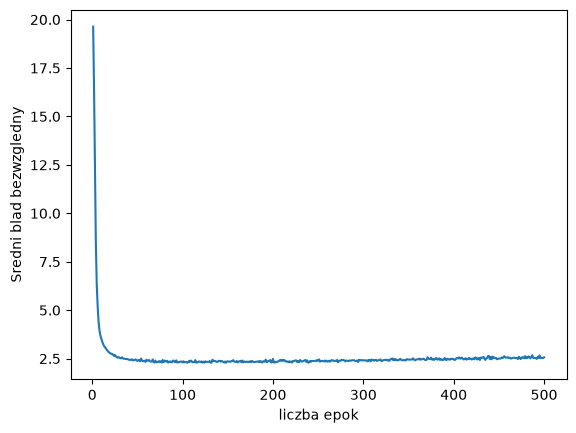

In [142]:
plt.plot(range(1, len(avg_mae_history) + 1), avg_mae_history)
plt.xlabel('liczba epok')
plt.ylabel('Sredni blad bezwzgledny')
plt.show()

In [143]:
def smooth_curve(points, factor =0.9):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

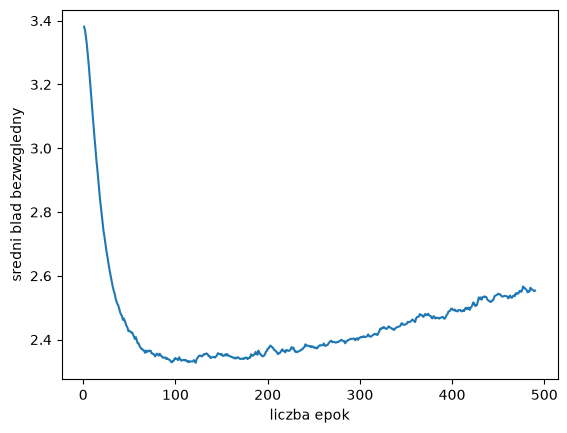

In [144]:
smooth_mae_history = smooth_curve(avg_mae_history[10:])

plt.plot(range(1, len(smooth_mae_history) + 1), smooth_mae_history)
plt.xlabel('liczba epok')
plt.ylabel('sredni blad bezwzgledny')
plt.show()

In [147]:
model = build_model()
model.fit(scaled_train_data, train_targets_3, epochs = 85, batch_size=16, verbose = 0)

test_mse_score, test_mae_score = model.evaluate(scaled_test_data, test_targets_3)
test_mae_score

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15.8046 - mae: 2.5491


2.5491297245025635

# testowanie walidacji na odlozonych danych

In [153]:
# 1. Tworzymy przykładowe dane (15 000 próbek)
data = np.random.randn(15000, 10)
targets = np.random.randint(0, 2, size=(15000,))


In [155]:
data.shape

(15000, 10)

In [156]:
targets

array([1, 0, 0, ..., 1, 0, 0], shape=(15000,), dtype=int32)

In [157]:
num_validation_samples

10000

In [158]:
indices = np.arange(len(data))
indices

array([    0,     1,     2, ..., 14997, 14998, 14999], shape=(15000,))

In [159]:
np.random.shuffle(indices)

In [161]:
data = data[indices]
data

array([[-0.08137957, -0.15595383,  2.39460566, ..., -0.07148366,
        -0.88424616,  2.37826858],
       [-0.87575107,  1.49569812, -1.91241471, ...,  0.54562336,
        -1.10562492,  0.10782191],
       [ 0.18652819,  0.40187052,  1.06341848, ...,  0.12781341,
         0.12265576, -1.28575348],
       ...,
       [-0.14676136, -1.58219325,  1.43101593, ..., -1.13788753,
        -0.99785568, -0.15810211],
       [ 0.39068816,  1.38280257, -1.75769263, ..., -1.19751524,
        -0.04290286, -1.24550357],
       [ 0.13969318,  0.62833261, -0.72260315, ...,  0.31400975,
        -0.50877033,  0.33115651]], shape=(15000, 10))

In [162]:
targets = targets[indices]
targets

array([1, 0, 0, ..., 1, 1, 1], shape=(15000,), dtype=int32)

In [172]:
validation_data_4 = data[9000:12000]
validation_targets_4 = targets[9000:12000]
test_data_4 = data[12000:]
test_targets_4 = targets[12000:]

In [173]:
training_data_4 = data[:9000]
training_targets_4 = targets[:9000]

In [174]:
model_7 = models.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
#sigmoid bo jest to klasyfikacja i wyrzuca liczby 0 lub 1

In [175]:
model_7.compile(
    optimizer='rmsprop',          # algorytm aktualizacji wag (np. rmsprop lub adam)
    loss='binary_crossentropy',   # funkcja straty (dla klasyfikacji binarnej)
    metrics=['accuracy']          # metryka czytelna dla człowieka
)

In [176]:
history_7 = model_7.fit(
    training_data,
    training_targets,
    epochs=20,
    batch_size=128,
    validation_data=(validation_data_4, validation_targets_4)
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5004 - loss: 0.7264 - val_accuracy: 0.5023 - val_loss: 0.7186
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5046 - loss: 0.7108 - val_accuracy: 0.5057 - val_loss: 0.7090
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5098 - loss: 0.7028 - val_accuracy: 0.5057 - val_loss: 0.7036
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5170 - loss: 0.6985 - val_accuracy: 0.5110 - val_loss: 0.7004
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5222 - loss: 0.6958 - val_accuracy: 0.5097 - val_loss: 0.6989
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5190 - loss: 0.6944 - val_accuracy: 0.5083 - val_loss: 0.6978
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5202 - loss: 0.6935 - val_accuracy: 0.5133 - val_loss: 0.6970
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5196 - loss: 0.6929 - val_accuracy: 0.5063 - val_loss:

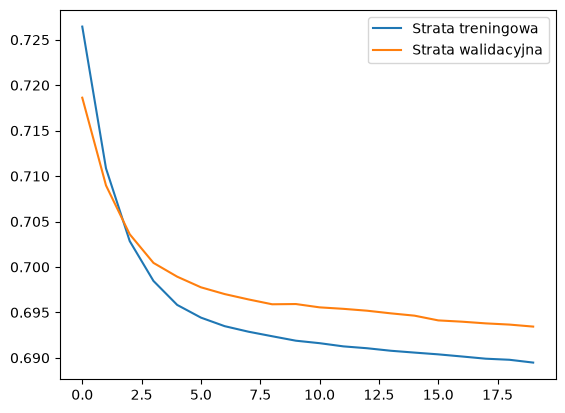

In [184]:
val_loss_7 = history_7.history['val_loss']
loss_7 = history_7.history['loss']

plt.plot(loss, label='Strata treningowa')
plt.plot(val_loss, label='Strata walidacyjna')
plt.legend()
plt.show()

# Overfitting poznajesz po rozjeździe dwóch krzywych: strata treningowa (loss) nadal spada w dół, a strata walidacyjna (val_loss) zaczyna odbijać w górę. Model uczy się szumu i kucia danych na pamięć zamiast ogólnych reguł.

In [185]:
import numpy as np

best_epoch = np.argmin(val_loss_7) + 1
print(f"Najlepszy punkt odcięcia to epoka numer: {best_epoch}")
print(f"Minimalny val_loss: {min(val_loss):.4f}")

Najlepszy punkt odcięcia to epoka numer: 20
Minimalny val_loss: 0.6934


In [189]:
final_model = models.Sequential([
    layers.Input(shape=(10,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
final_model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
final_model.fit(
    np.concatenate([training_data_4, validation_data_4]),
    np.concatenate([training_targets_4, validation_targets_4]),
    epochs=20,
    batch_size=128,
    verbose=0
)

# Do ok. 100–120 epoki: Obie linie spadają. Model uczy się prawdziwych, ogólnych wzorców z danych.

# Okolice 100–158 epoki (Dolina): Osiągasz sweet spot. W 158. epoce błąd walidacyjny wynosi minimum (10.0458).

# Powyżej 160 epoki: Czyste przeuczenie. Niebieska linia (trening) dalej spada do ~1.0, a pomarańczowa (walidacja) leci z powrotem w górę aż do ~17.5. Każda epoka po 158. tylko psuła model na nowych danych.

# Dokładnie tak. Minimum val_loss to Twój jedyny punkt docelowy.

# Wyznacza on optymalną liczbę epok:

# Przed tym punktem: model jest niedouczony (underfitting) — wciąż może nauczyć się przydatnych zależności.

# W tym punkcie: maksymalna zdolność generalizacji — model najlepiej radzi sobie z nieznanymi danymi.

# Po tym punkcie: przeuczenie (overfitting) — błąd na nowych danych rośnie, bo sieć zaczyna uczyć się szumu na pamięć.

In [190]:
test_loss, test_acc = final_model.evaluate(test_data_4, test_targets_4)
print(f"Błąd testowy: {test_loss:.4f} | Dokładność testowa: {test_acc:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step - accuracy: 0.4783 - loss: 0.6996
Błąd testowy: 0.6996 | Dokładność testowa: 0.4783
